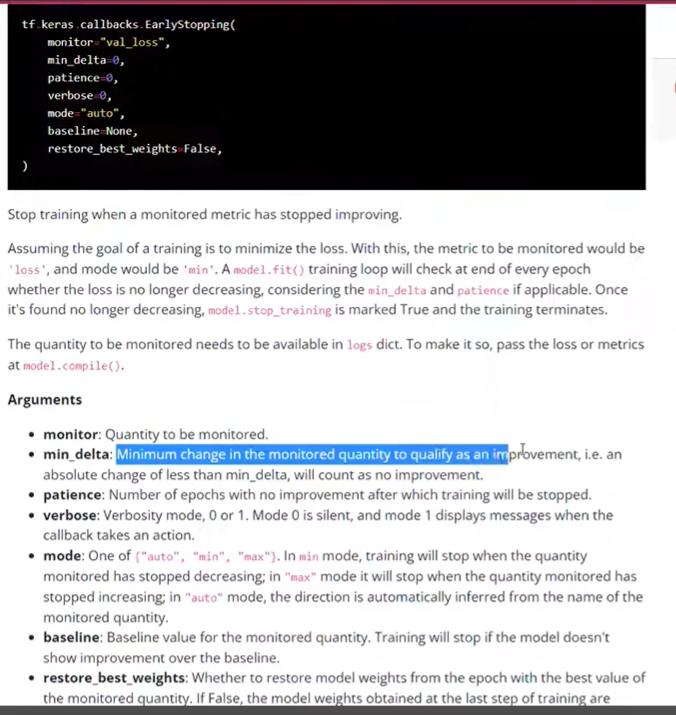

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [6]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

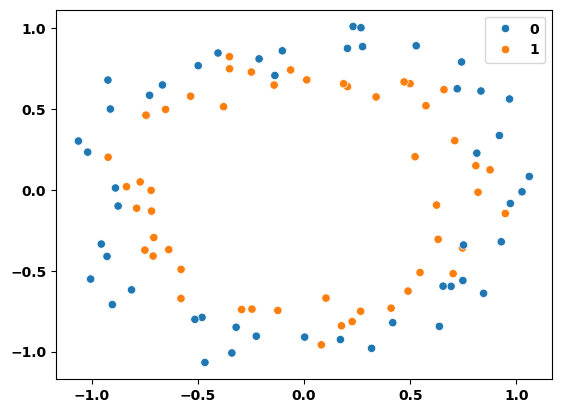

In [7]:
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y
)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [9]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\Home\anaconda3\envs\eda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=500, verbose=0)

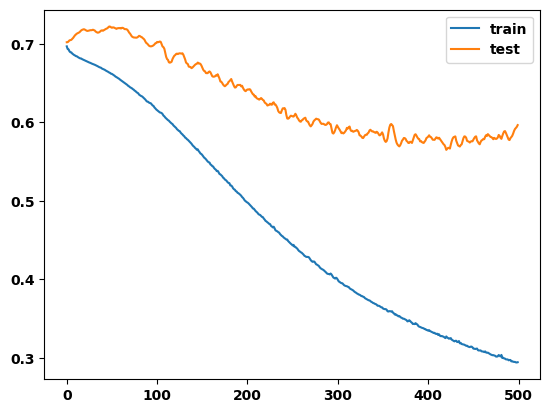

In [12]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


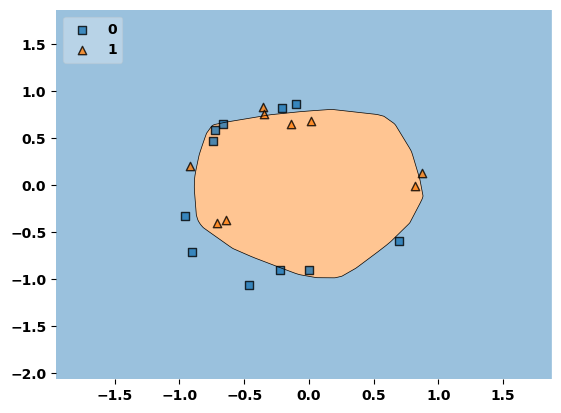

In [13]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

# Early Stopping

In [14]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [15]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [17]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 509ms/step - accuracy: 0.4750 - loss: 0.6946 - val_accuracy: 0.5500 - val_loss: 0.6841
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.5000 - loss: 0.6921 - val_accuracy: 0.5500 - val_loss: 0.6881
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5000 - loss: 0.6901 - val_accuracy: 0.5500 - val_loss: 0.6913
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5375 - loss: 0.6890 - val_accuracy: 0.4500 - val_loss: 0.6953
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5375 - loss: 0.6872 - val_accuracy: 0.4000 - val_loss: 0.6982
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5375 - loss: 0.6864 - val_accuracy: 0.4000 - val_loss: 0.7012
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5625 - loss: 0.6850 - val_accuracy: 0.4000 - val_loss: 0.7039
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5750 - loss: 0.6844 - val_accuracy: 0.4000 

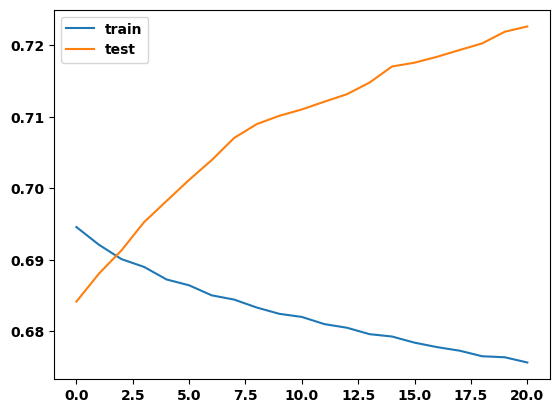

In [18]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step


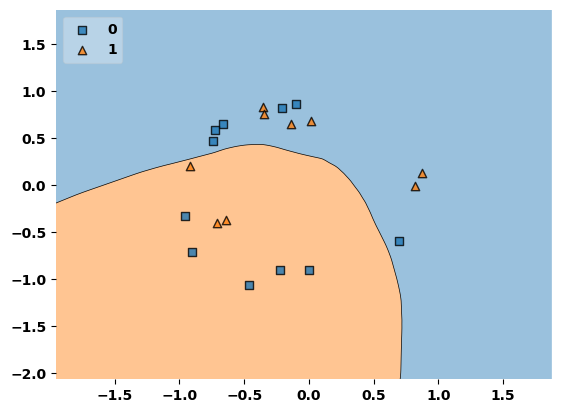

In [19]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

Early stopping stops training when validation performance stops improving, preventing overfitting.

Early stopping is a technique used to stop training at the right time so the model does not overfit.

# 🌱 Simple Definition

Early stopping means:

Stop training when the model stops improving on new (validation) data, even if training accuracy keeps increasing.

# 🧩 Best Analogy 
Studying for an Exam 📚

Studying helps at first ✅

Studying too much causes confusion & burnout ❌

👉 Stopping at the right time gives best results
That’s early stopping.

# 🔄 How Early Stopping Works

1️⃣ Split data into:

Training data

Validation data

2️⃣ Train the model in epochs

3️⃣ After each epoch:

Check performance on validation data

4️⃣ If validation performance:

Improves → continue training

Stops improving → stop training ✋

# 📉 What Problem It Solves
Overfitting ❌

Training accuracy ↑

Validation accuracy ↓

Early stopping prevents this.

Accuracy
│        Training
│         ↑ ↑ ↑
│       Validation
│      ↑ ↑ ↓ ↓
└────────────── Epochs
        ↑
   Stop here (Early Stopping)


# Why Early Stopping Is Important

✔ Improves generalization
✔ Saves training time
✔ Acts like regularization
✔ Very easy to apply

| Parameter | Meaning                     |
| --------- | --------------------------- |
| Monitor   | val_loss / val_accuracy     |
| Patience  | How long to wait            |
| Mode      | min (loss) / max (accuracy) |


Data scaling (also called feature scaling) means bringing all input features to a similar range so a neural network can learn properly.

# 🌱 Simple Definition

Feature scaling means:

Adjusting input values so no feature dominates others just because of its size.

# 🧩 Best Analogy 
Comparing Apples 🍎 and Elephants 🐘

Feature A range: 0–10

Feature B range: 0–10,000

The bigger one overpowers the smaller one.

👉 Scaling makes them comparable.

# 🔄 Why Feature Scaling Is Important in ANN

Without scaling:
❌ Slow learning
❌ Unstable training
❌ Vanishing / exploding gradients
❌ Poor accuracy

With scaling:
✅ Faster convergence
✅ Stable gradients
✅ Better performance

# What Happens Inside a Neural Network

Neural networks:

Multiply inputs by weights

Add them

Pass through activation functions

Large input values → very large updates → learning problems
Scaling fixes this.

# 📐 Common Feature Scaling Methods
✅ 1. Normalization (Min-Max Scaling)

Scales data between 0 and 1

📌 Best when:

Data has a known range

No extreme outliers

Example idea:
Marks out of 100 → divide by 100

✅ 2. Standardization (Z-Score Scaling) ⭐

Scales data to:

Mean = 0

Standard deviation = 1

📌 Best for:

Neural networks

Most ML models

✅ 3. Robust Scaling

Uses median & interquartile range

📌 Best when:

Data has many outliers

| Method          | Range        | Best Use              |
| --------------- | ------------ | --------------------- |
| Normalization   | 0 to 1       | Bounded data          |
| Standardization | Mean 0, SD 1 | ANN / Deep Learning ⭐ |
| Robust Scaling  | Outlier-safe | Noisy data            |


⚠️ Very Important Rule

🚫 Never scale test data separately

✔ Fit scaler on training data
✔ Apply same scaler to test data


🔑 Key Takeaway

📌 Always scale data before training an ANN

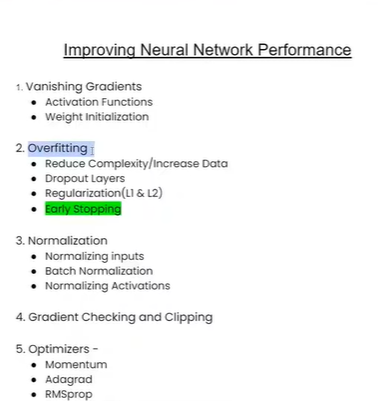

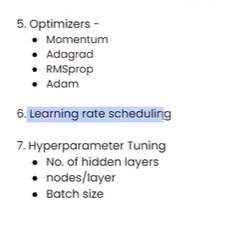

https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqbWUxdHVEWFZVN2dPS1dDMVZEbFBxbXl1R0tMd3xBQ3Jtc0trenNsbDBVeW5TWFptR0tFRHFJZXlwQi1DZmQyMWtDdDNEZkNSWGY3UHJNY3M1UFB2bnRES1c4WXJINGo0ZmRmWElhdmJIemE1QnZNSVV3TTRoMHZ0b0FueTNudXJCMVpaOENPN0trcnpwOXlsMHpoMA&q=https%3A%2F%2Fcolab.research.google.com%2Fdrive%2F1lexRUY37fJd6op-WiJicPRB65PwA8YaO%3Fusp%3Dsharing&v=mzRO0cVppQ0

if unscale data we do it standarized or normalize

if scale varry (one is big and second oen is short) on that type of input when we train nn(train maybe too slow or nstable and we cannot get good results )

# so we need to keep data on same scale. 
for this we ahve two methods one is standarization and second one is normalization . 

we do standarization when data is normaly distributed and normalozation when we know what is min max values or we know about outliers



# 🔢 Normalizing Inputs in Neural Networks

Normalizing inputs means scaling input values to a fixed, small range, usually 0 to 1, so a neural network can learn efficiently.

# Simple Definition

Input normalization means:

Converting input features into a common scale so no feature dominates the learning process.

# 🧩 Best Analogy 
Adjusting Volume Levels 🔊

One sound is very loud

Another is very quiet

You adjust both to the same volume range
👉 That is normalization.

# 🔄 Why Normalizing Inputs Is Important

Without normalization:
❌ Slow learning
❌ Unstable training
❌ Vanishing/exploding gradients
❌ Poor convergence

With normalization:
✅ Faster training
✅ Stable gradients
✅ Better accuracy
✅ Smoother loss curve

# 📐 Common Normalization Methods
✅ 1. Min-Max Normalization (Most Common)

Scales values between 0 and 1

Idea:

(value − min) / (max − min)


📌 Used when:

Data has fixed bounds

No extreme outliers

✅ 2. Mean Normalization

Centers data around zero

📌 Used when:

Data is fairly symmetric

✅ 3. Z-Score Normalization (Standardization)

Mean = 0, Standard Deviation = 1

📌 Often preferred for ANN & Deep Learning


| Feature    | Original | Normalized |
| ---------- | -------- | ---------- |
| CGPA       | 9.0      | 0.90       |
| Experience | 2 years  | 0.20       |
| Score      | 80       | 0.80       |


⚠️ Important Rule 

✔ Fit normalization on training data only
✔ Apply the same transformation to test data

🚫 Never normalize train and test separately

 Summary

Normalizing inputs ensures balanced learning by keeping feature values within a similar range.



Normalizing inputs is a preprocessing technique that scales features to a common range, improving convergence speed and stability in neural networks.

🔑 Key Takeaway

📌 Always normalize inputs before training a neural network